# Laboratorio 5 — Clasificación de tweets usando minería de texto
### CC3084 — Data Science | Universidad del Valle de Guatemala
### Avance — 27 de agosto de 2026

Dataset: [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started) (Kaggle).

Este notebook cubre la entrega de **avance**:
1. Carga y descripción de los datos
2. Preprocesamiento de texto
3. Frecuencia de palabras (unigramas y bigramas)
4. Análisis exploratorio de datos (EDA): palabra top por categoría, nube de palabras, histograma, palabras en común
5. Descripción del enfoque preliminar de clasificación

La función de clasificación final, el análisis de sentimiento y el informe se entregan en la fase final (30 de agosto).

In [1]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Emadlg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Emadlg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Emadlg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

STOPWORDS = set(stopwords.words("english"))
print("Listo.")

Listo.


## 1. Carga de datos

In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("train:", train.shape)
print("test:", test.shape)
train.head()

train: (7613, 5)
test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Descripción del dataset

El set de entrenamiento tiene 5 columnas: `id`, `keyword`, `location`, `text` y `target` (1 = desastre real, 0 = no lo es).
Revisamos tipos de dato, valores nulos y balance de clases.

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [5]:
nulos = train.isna().sum()
porcentaje = (train.isna().mean() * 100).round(2)
pd.DataFrame({"nulos": nulos, "%": porcentaje})

,nulos,%
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


**Observación:** `keyword` tiene muy pocos nulos (~0.8%), pero `location` tiene un ~33% de valores faltantes y además es texto libre (no estandarizado, ej. "New York", "NYC", "usa"), por lo que su utilidad directa como feature es limitada sin un preprocesamiento geográfico adicional. Para este laboratorio nos enfocamos en `text` como fuente principal de información.

C:\Users\Emadlg\AppData\Local\Temp\ipykernel_17748\2265251680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="target", ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\Emadlg\AppData\Local\Temp\ipykernel_17748\2265251680.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No es desastre (0)", "Desastre real (1)"])


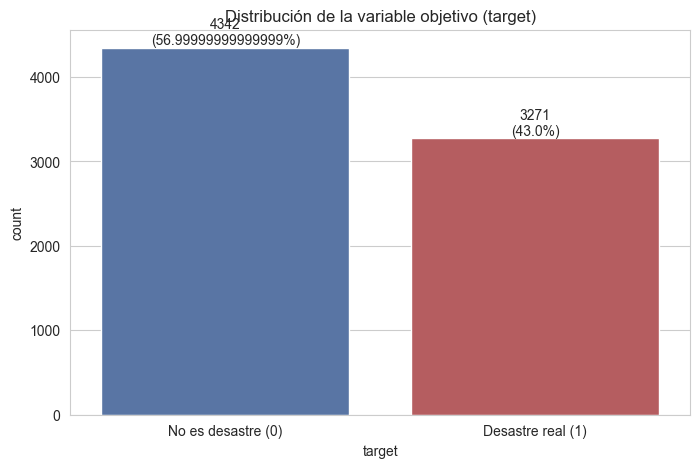

target
0    4342
1    3271
Name: count, dtype: int64

In [6]:
conteo = train["target"].value_counts()
porcentaje_t = train["target"].value_counts(normalize=True).round(3) * 100

fig, ax = plt.subplots()
sns.countplot(data=train, x="target", ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No es desastre (0)", "Desastre real (1)"])
ax.set_title("Distribución de la variable objetivo (target)")
for i, v in enumerate(conteo.sort_index()):
    ax.text(i, v + 40, f"{v}\n({porcentaje_t.sort_index().iloc[i]}%)", ha="center")
plt.show()

conteo

**Observación:** las clases están razonablemente balanceadas (57% no-desastre vs 43% desastre real), por lo que no es indispensable aplicar técnicas de balanceo (oversampling/undersampling) para el modelo preliminar, aunque se puede revisar más adelante si el desempeño lo amerita.

Longitud promedio de tweet (caracteres): 101.0
Palabras clave (keyword) distintas: 221
Ubicaciones (location) distintas: 3341


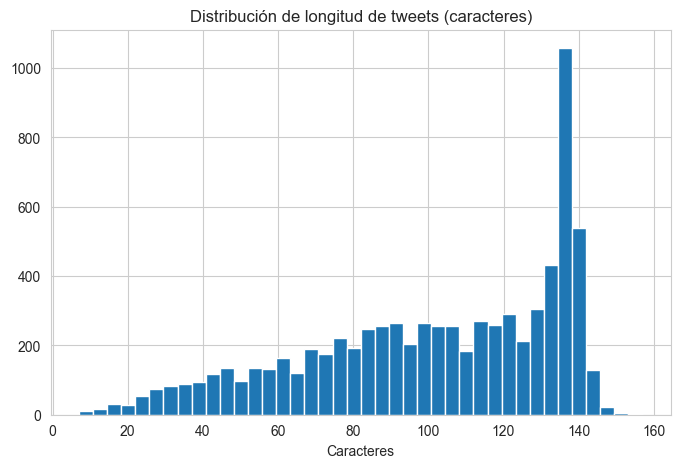

In [7]:
print("Longitud promedio de tweet (caracteres):", train["text"].str.len().mean().round(1))
print("Palabras clave (keyword) distintas:", train["keyword"].nunique())
print("Ubicaciones (location) distintas:", train["location"].nunique())

fig, ax = plt.subplots()
train["text"].str.len().hist(bins=40, ax=ax)
ax.set_title("Distribución de longitud de tweets (caracteres)")
ax.set_xlabel("Caracteres")
plt.show()

## 3. Limpieza y preprocesamiento de los datos

Aplicamos los siguientes pasos, en este orden, y explicamos la decisión detrás de cada uno:

1. **Minúsculas**: normaliza el texto para que "Fire" y "fire" se traten como la misma palabra.
2. **Eliminar URLs**: los links (`http://...`) no aportan significado semántico y son ruido de alta cardinalidad.
3. **Eliminar menciones (@usuario)**: nombres de usuario son ruido, no aportan a clasificar el contenido.
4. **Eliminar el símbolo `#` pero conservar la palabra del hashtag**: el hashtag suele llevar información temática relevante (ej. `#earthquake` → `earthquake`), así que solo quitamos el símbolo, no la palabra.
5. **Eliminar emojis/emoticones**: se remueven caracteres Unicode fuera del rango ASCII estándar de texto.
6. **Eliminar signos de puntuación y apóstrofes**.
7. **Eliminar números, EXCEPTO "911"**: decidimos conservar "911" porque es una palabra clave fuertemente asociada a emergencias reales (llamadas de auxilio), mientras que otros números (fechas, cantidades) generalmente no aportan valor discriminativo y sí añaden dispersión al vocabulario.
8. **Eliminar stopwords en inglés** (artículos, preposiciones, conjunciones) usando el corpus de NLTK.
9. **Eliminar espacios múltiples y espacios al inicio/fin**.

Los tweets están en inglés, así que usamos el corpus de stopwords de NLTK para ese idioma.

In [8]:
def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    t = texto.lower()                                   # 1. minúsculas
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)         # 2. URLs
    t = re.sub(r"@\w+", " ", t)                          # 3. menciones
    t = t.replace("#", " ")                              # 4. quitar # pero dejar la palabra
    t = re.sub(r"[^\x00-\x7F]+", " ", t)                 # 5. emojis / caracteres no-ascii
    t = re.sub(r"911", " NUM911 ", t)                    # 6a. proteger "911" antes de quitar números
    t = re.sub(r"\d+", " ", t)                            # 6b. quitar el resto de números
    t = t.replace("NUM911", "911")                       # 6c. restaurar "911"
    t = t.translate(str.maketrans("", "", string.punctuation))  # 7. puntuación / apóstrofes
    tokens = t.split()
    tokens = [tok for tok in tokens if tok not in STOPWORDS and len(tok) > 1]  # 8. stopwords
    return " ".join(tokens)

train["text_clean"] = train["text"].apply(limpiar_texto)
test["text_clean"] = test["text"].apply(limpiar_texto)

train[["text", "text_clean"]].head(10)

,text,text_clean
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,im top hill see fire woods
8,There's an emergency evacuation happening now ...,theres emergency evacuation happening building...
9,I'm afraid that the tornado is coming to our a...,im afraid tornado coming area


**Ejemplo antes/después con un tweet que menciona `911`:**

In [9]:
ejemplo = train[train["text"].str.contains("911", na=False)].iloc[0]
print("ANTES:", ejemplo["text"])
print("DESPUES:", ejemplo["text_clean"])

ANTES: @_jeesss_ @Ethereal_7 Hello 911 yeah we have someone drowning here send a medic http://t.co/7GiglwdMhy
DESPUES: hello NUM yeah someone drowning send medic


## 4. Frecuencia de palabras (unigramas y bigramas)

Calculamos la frecuencia de palabras por separado para tweets de desastre real (`target=1`) y no-desastre (`target=0`), para identificar qué palabras son más discriminativas.

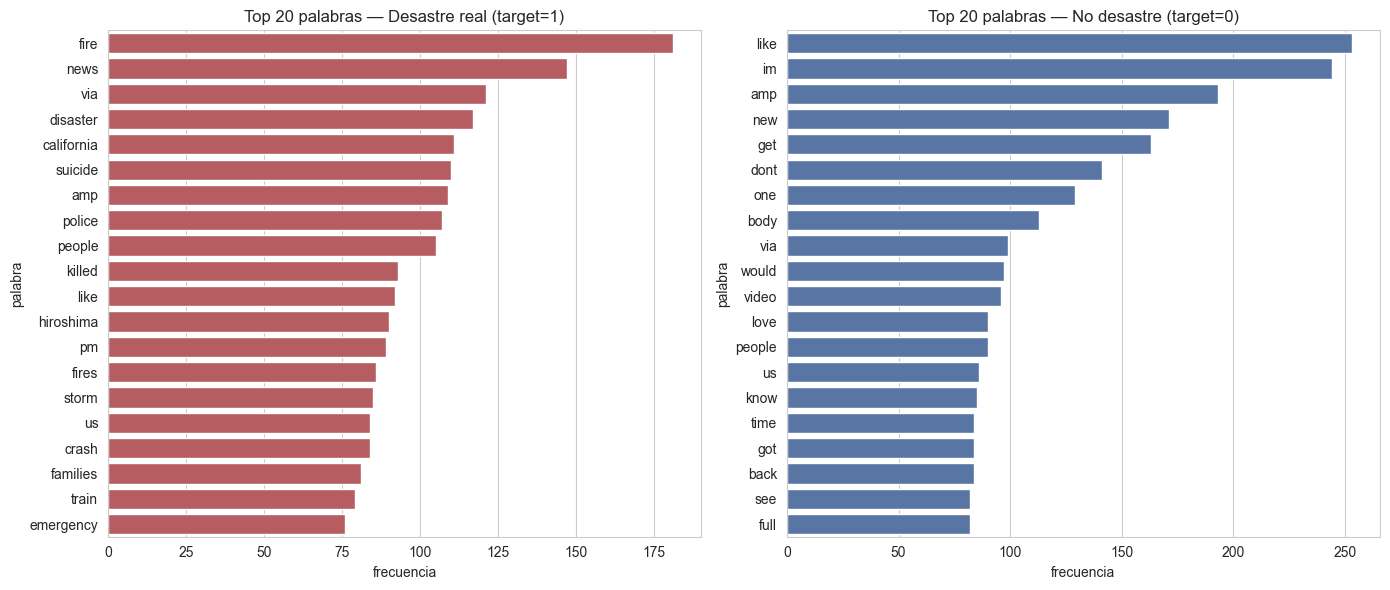

In [10]:
def top_palabras(serie_texto, n=20):
    palabras = " ".join(serie_texto).split()
    return Counter(palabras).most_common(n)

top_desastre = top_palabras(train.loc[train.target == 1, "text_clean"])
top_no_desastre = top_palabras(train.loc[train.target == 0, "text_clean"])

df_top_desastre = pd.DataFrame(top_desastre, columns=["palabra", "frecuencia"])
df_top_no_desastre = pd.DataFrame(top_no_desastre, columns=["palabra", "frecuencia"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=df_top_desastre, y="palabra", x="frecuencia", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 20 palabras — Desastre real (target=1)")
sns.barplot(data=df_top_no_desastre, y="palabra", x="frecuencia", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 20 palabras — No desastre (target=0)")
plt.tight_layout()
plt.show()

**Observación:** en los tweets de desastre real predominan palabras muy asociadas a eventos catastróficos concretos (ej. `fire`, `flood`, `disaster`, `killed`, `california`, `storm`), mientras que en los de no-desastre aparecen palabras más genéricas o usadas en sentido figurado/metáfora (ej. `like`, `new`, `via`, `body` en contexto no literal). Esto sugiere que un modelo basado en frecuencia de palabras (bag-of-words / TF-IDF) ya puede capturar señal útil, aunque el reto está en los tweets que usan palabras de "desastre" en sentido no literal (ironía, metáfora), donde el contexto (bigramas/trigramas) puede ayudar.

In [11]:
palabras_comunes = (set(df_top_desastre["palabra"]) & set(df_top_no_desastre["palabra"]))
print("Palabras que aparecen en el top 20 de ambas categorías:", palabras_comunes)

Palabras que aparecen en el top 20 de ambas categorías: {'people', 'like', 'via', 'amp', 'us'}


### Bigramas por categoría

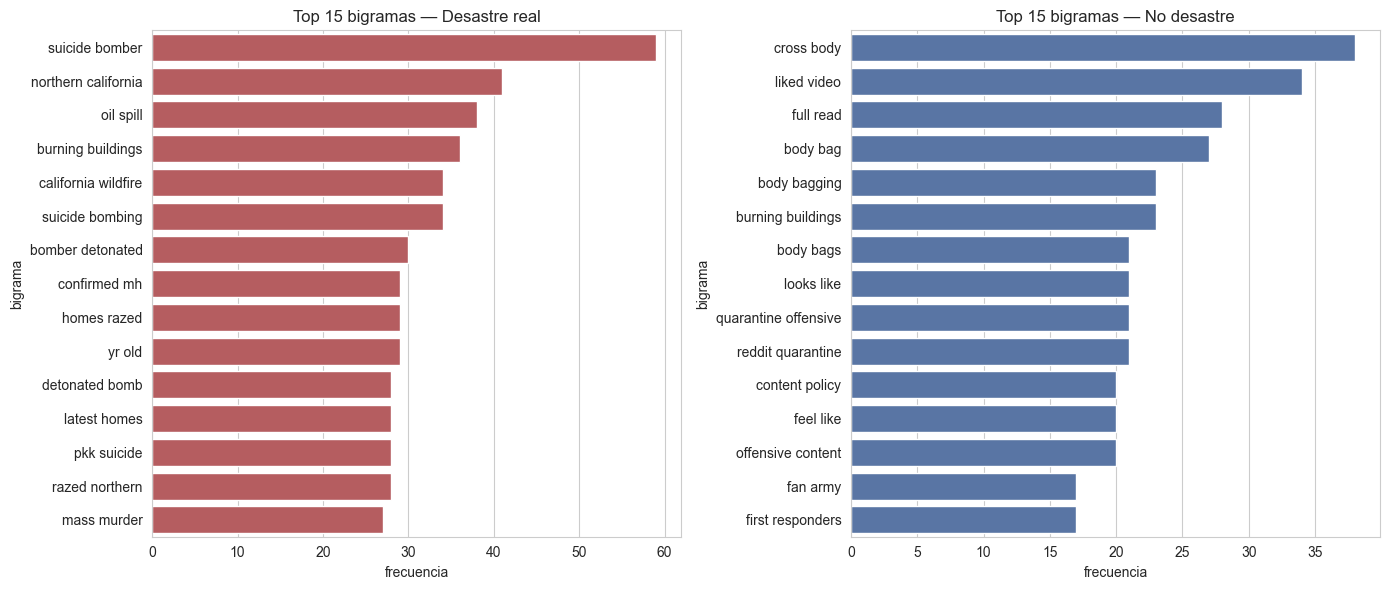

In [12]:
def top_ngramas(serie_texto, n_gram=2, top_n=15):
    vec = CountVectorizer(ngram_range=(n_gram, n_gram))
    matriz = vec.fit_transform(serie_texto)
    frecuencias = matriz.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    conteo = sorted(zip(vocab, frecuencias), key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame(conteo, columns=["bigrama", "frecuencia"])

bigramas_desastre = top_ngramas(train.loc[train.target == 1, "text_clean"])
bigramas_no_desastre = top_ngramas(train.loc[train.target == 0, "text_clean"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=bigramas_desastre, y="bigrama", x="frecuencia", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 15 bigramas — Desastre real")
sns.barplot(data=bigramas_no_desastre, y="bigrama", x="frecuencia", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 15 bigramas — No desastre")
plt.tight_layout()
plt.show()

**¿Vale la pena explorar bigramas/trigramas?** Sí. Los bigramas capturan combinaciones como `suicide bomber`, `northern california`, `oil spill`, que son mucho más específicas y menos ambiguas que las palabras sueltas que las componen. Esto es clave para resolver casos donde una palabra individual (ej. "fire" en "I'm on fire today lol" vs. "wildfire") es ambigua fuera de contexto. Probaremos trigramas más adelante si el aporte marginal de los bigramas es significativo, pero dado que los tweets son cortos (~15 palabras en promedio tras la limpieza), es probable que los trigramas generen mucha dispersión (features muy raras) con poco beneficio adicional — algo a validar empíricamente en la fase de modelado.

## 5. Análisis exploratorio de los datos (EDA)

Profundizamos el análisis exploratorio: qué palabra se repite más en cada categoría, nube de palabras, histograma de las palabras más frecuentes, y qué palabras/keywords tienen presencia en ambas categorías.

### 5.1 Palabra que más se repite en cada categoría

In [13]:
palabra_top_desastre, freq_top_desastre = top_palabras(train.loc[train.target == 1, "text_clean"], n=1)[0]
palabra_top_no_desastre, freq_top_no_desastre = top_palabras(train.loc[train.target == 0, "text_clean"], n=1)[0]

print(f"Desastre real (target=1): '{palabra_top_desastre}' con {freq_top_desastre} apariciones")
print(f"No desastre (target=0): '{palabra_top_no_desastre}' con {freq_top_no_desastre} apariciones")

Desastre real (target=1): 'fire' con 181 apariciones
No desastre (target=0): 'like' con 253 apariciones


### 5.2 Nube de palabras por categoría

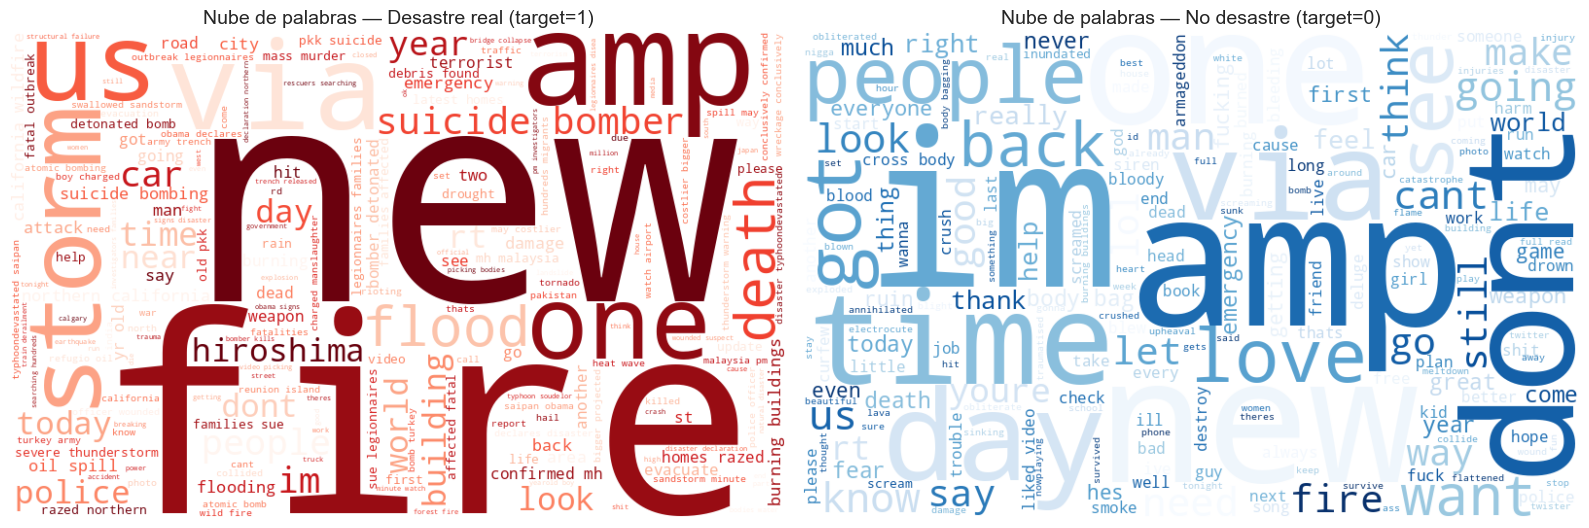

In [14]:
from wordcloud import WordCloud

texto_desastre = " ".join(train.loc[train.target == 1, "text_clean"])
texto_no_desastre = " ".join(train.loc[train.target == 0, "text_clean"])

wc_desastre = WordCloud(width=800, height=500, background_color="white", colormap="Reds").generate(texto_desastre)
wc_no_desastre = WordCloud(width=800, height=500, background_color="white", colormap="Blues").generate(texto_no_desastre)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_desastre, interpolation="bilinear")
axes[0].set_title("Nube de palabras — Desastre real (target=1)", fontsize=14)
axes[0].axis("off")
axes[1].imshow(wc_no_desastre, interpolation="bilinear")
axes[1].set_title("Nube de palabras — No desastre (target=0)", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Observación:** la nube de palabras confirma visualmente el patrón detectado con las frecuencias: en desastre real dominan términos concretos de catástrofes (`fire`, `flood`, `disaster`, `storm`, `killed`, `california`), mientras que en no-desastre predominan palabras de uso cotidiano/coloquial y expresiones usadas en sentido figurado (`like`, `new`, `body`, `via`, `love`).

### 5.3 Histograma de las palabras más frecuentes (global)

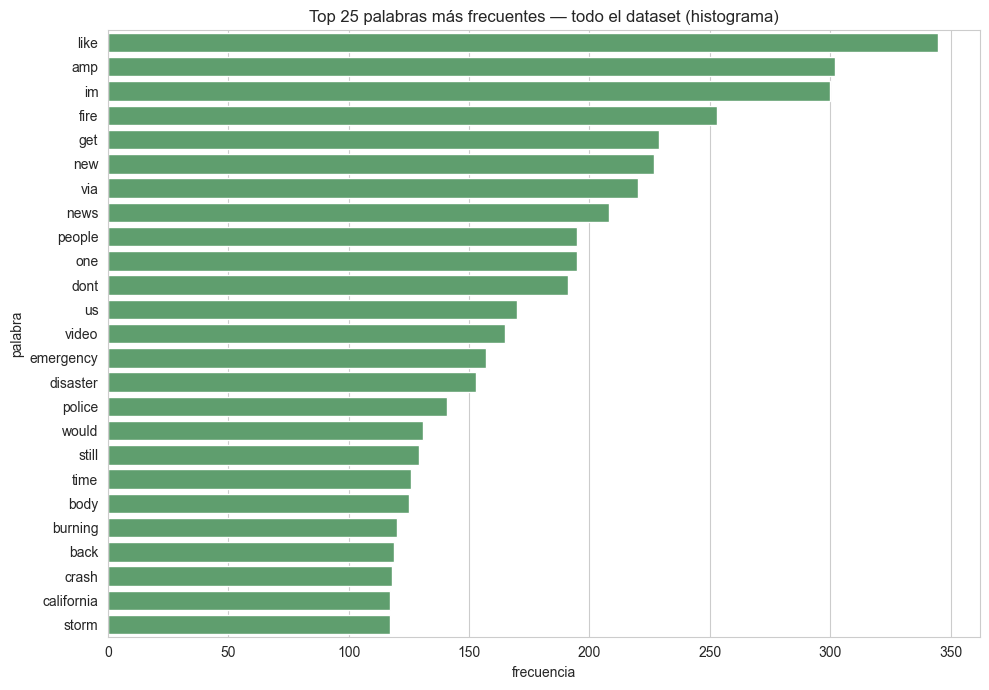

In [15]:
todas_palabras = " ".join(train["text_clean"]).split()
top_global = Counter(todas_palabras).most_common(25)
df_top_global = pd.DataFrame(top_global, columns=["palabra", "frecuencia"])

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=df_top_global, y="palabra", x="frecuencia", ax=ax, color="#55A868")
ax.set_title("Top 25 palabras más frecuentes — todo el dataset (histograma)")
plt.tight_layout()
plt.show()

### 5.4 Palabras y keywords presentes en ambas categorías

In [16]:
set_desastre_100 = set([p for p, _ in top_palabras(train.loc[train.target == 1, "text_clean"], n=100)])
set_no_desastre_100 = set([p for p, _ in top_palabras(train.loc[train.target == 0, "text_clean"], n=100)])
comunes_100 = set_desastre_100 & set_no_desastre_100

print(f"De las 100 palabras más frecuentes de cada categoría, {len(comunes_100)} aparecen en ambas:")
print(sorted(comunes_100))

De las 100 palabras más frecuentes de cada categoría, 28 aparecen en ambas:
['amp', 'back', 'burning', 'could', 'death', 'disaster', 'dont', 'emergency', 'fire', 'first', 'get', 'im', 'like', 'man', 'may', 'new', 'news', 'one', 'people', 'rt', 'say', 'still', 'time', 'today', 'us', 'via', 'video', 'world']


In [17]:
# Cruce con la columna 'keyword': ¿qué keywords aparecen en ambas categorías?
keyword_por_target = train.dropna(subset=["keyword"]).groupby("keyword")["target"].agg(["mean", "count"])
keyword_mixtas = keyword_por_target[(keyword_por_target["mean"] > 0.2) & (keyword_por_target["mean"] < 0.8) & (keyword_por_target["count"] >= 10)]
keyword_mixtas.sort_values("count", ascending=False).head(10)

,mean,count
keyword,,
fatalities,0.577778,45
damage,0.463415,41
evacuate,0.625000,40
collided,0.575000,40
windstorm,0.400000,40
famine,0.666667,39
collision,0.743590,39
flames,0.333333,39
weapons,0.435897,39


**Discusión:** hay un conjunto de palabras (conectores, verbos genéricos, pronombres residuales que sobrevivieron el filtro de stopwords, y algunas palabras muy comunes como `people`, `via`, `will`, `new`) que aparecen con frecuencia similar en ambas categorías — son palabras **poco discriminativas** por sí solas para el modelo. Lo mismo ocurre con varias `keyword` (ej. términos ambiguos como `wrecked`, `deluge`, `panic`) que se usan tanto en tweets de desastre real como en tweets con esa palabra en sentido figurado o de broma. Esto refuerza la idea de que el contexto (bigramas) y no solo la palabra aislada, es clave para separar bien ambas clases.

## 6. Descripción del modelo preliminar de clasificación

**Enfoque:** dado que el problema requiere capturar tanto palabras individuales relevantes como combinaciones de palabras (contexto), planteamos representar cada tweet con **TF-IDF** (Term Frequency – Inverse Document Frequency) considerando **unigramas y bigramas** (`ngram_range=(1,2)`), lo cual permite que el modelo aproveche tanto palabras sueltas discriminativas (`fire`, `killed`) como combinaciones con contexto (`suicide bomber`).

Como modelo preliminar probamos dos algoritmos simples y rápidos, típicos para clasificación de texto:
- **Regresión Logística**: buen baseline lineal para texto disperso de alta dimensión (TF-IDF).
- **Naive Bayes Multinomial**: clásico para clasificación de texto, funciona bien con conteos de palabras.

Se hace un split 80/20 (train/test) sobre el set de entrenamiento para tener una primera métrica de referencia. **Esto es solo un modelo preliminar** — en la entrega final se probarán más algoritmos (ej. SVM, Random Forest, embeddings), se hará tuning de hiperparámetros y se seleccionará el mejor modelo con base en métricas como F1-score (más adecuado que accuracy dado que hay un leve desbalance de clases).

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    train["text_clean"], train["target"], test_size=0.2, random_state=42, stratify=train["target"]
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Dimensiones de la matriz TF-IDF (train):", X_train_tfidf.shape)

Dimensiones de la matriz TF-IDF (train): (6090, 9283)


In [19]:
modelos = {
    "Regresion Logistica": LogisticRegression(max_iter=1000),
    "Naive Bayes Multinomial": MultinomialNB(),
}

resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    pred = modelo.predict(X_val_tfidf)
    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred)
    resultados.append({"modelo": nombre, "accuracy": round(acc, 4), "f1_score": round(f1, 4)})

df_resultados = pd.DataFrame(resultados)
df_resultados

,modelo,accuracy,f1_score
0,Regresion Logistica,0.8273,0.7821
1,Naive Bayes Multinomial,0.8168,0.7593


**Resultado preliminar:** ambos modelos ya logran resultados razonables como punto de partida (por encima del baseline ingenuo de ~57%, que es predecir siempre la clase mayoritaria). Esto confirma que la representación TF-IDF con unigramas + bigramas captura señal útil para este problema. En la entrega final se explorará: incluir la variable `keyword`, probar otros algoritmos, ajustar hiperparámetros, y evaluar con validación cruzada.

## Resumen del avance

- Se cargaron y describieron los datos (7,613 tweets de entrenamiento, clases balanceadas ~57/43, `location` con 33% de nulos).
- Se aplicó un pipeline de limpieza de texto (minúsculas, URLs, menciones, hashtags, emojis, puntuación, números conservando "911", stopwords).
- Se calcularon frecuencias de unigramas y bigramas por categoría, identificando palabras y combinaciones discriminativas.
- Se hizo un análisis exploratorio (EDA): palabra más repetida por categoría, nube de palabras, histograma global de frecuencias, y se identificaron palabras/keywords con presencia en ambas categorías (poco discriminativas).
- Se planteó y probó un modelo preliminar (TF-IDF + Regresión Logística / Naive Bayes) como punto de partida.

**Pendiente para la entrega final (30 de agosto):** análisis exploratorio completo (nube de palabras, cruces de variables), selección y evaluación rigurosa del mejor modelo, función de clasificación para tweets nuevos sin preprocesar, análisis de sentimiento (positivo/negativo/neutro), variable de "negatividad" y reentrenamiento, e informe final con todos los hallazgos.